# DBSCAN

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import ParameterGrid
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Stile dei grafici
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

## Caricamento e Preparazione dei Dati

In [37]:
# Caricamento del dataset
df = pd.read_csv('finale01_preprocessed.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColonne disponibili:\n{df.columns.tolist()}")
df.head()

Dataset shape: (21244, 30)

Colonne disponibili:
['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'InterestScore', 'NumWeightVotes', 'log_NumWeightVotes', 'PlaytimeComAvg', 'NumUserRatings', 'log_NumUserRatings', 'NumAlternates', 'NumAlternates_log', 'NumExpansions', 'NumExpansions_log', 'NumImplementations', 'NumImplementations_log', 'IsReimplementation', 'Kickstarted', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating', 'InterestScore_log']


,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,log_NumWeightVotes,PlaytimeComAvg,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,InterestScore_log
0,Assassin's Creed: Arena,2014,1.8333,2,4,8.0,199.333333,6,1.945910,30.0,...,0,0,0,0,0,0,0,0,1,5.299983
1,Bag of Chips,2021,1.0000,2,5,8.0,43.666667,6,1.945910,17.5,...,0,0,0,0,0,0,0,0,2,3.799228
2,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,10.0,311.333333,9,2.302585,90.0,...,0,0,0,0,0,0,0,0,3,5.744071
3,LetterFlip,2004,1.3077,2,2,7.0,54.333333,13,2.639057,20.0,...,0,0,0,0,0,0,0,0,1,4.013375
4,Treasures of Cibola,2019,1.5000,2,4,10.0,82.333333,2,1.098612,17.5,...,0,0,0,0,0,0,0,0,2,4.422849


In [38]:
# Statistiche descrittive
df.describe()

,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,log_NumWeightVotes,PlaytimeComAvg,NumUserRatings,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,InterestScore_log
count,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,...,21244.000000,21244.000000,21244.00000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000,21244.000000
mean,2007.343156,96.363361,2.001177,4.669883,44.865312,507.281287,49.393899,2.568811,67.454717,863.704199,...,0.057193,0.108642,0.16447,0.105771,0.014169,0.048061,0.027396,0.038976,1.908398,5.114573
std,12.688005,473.867005,0.656622,2.369266,591.752445,1210.955011,206.279180,1.371031,77.373744,3657.417590,...,0.232216,0.311197,0.37071,0.307552,0.118189,0.213899,0.163238,0.193542,0.740797,1.332688
min,1950.000000,1.000000,1.000000,1.000000,2.000000,2.000000,0.000000,0.000000,1.000000,30.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.098612
25%,2002.000000,1.400000,2.000000,4.000000,8.000000,61.000000,4.000000,1.609438,25.000000,56.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.127134
50%,2012.000000,2.000000,2.000000,4.000000,10.000000,129.000000,9.000000,2.302585,45.000000,124.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.867534
75%,2017.000000,2.666700,2.000000,6.000000,12.000000,363.000000,26.000000,3.295837,75.000000,398.250000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5.897154
max,2021.000000,4708.000000,9.000000,20.000000,16625.000000,8671.256667,7673.000000,8.945593,480.000000,108101.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,9.067884


In [71]:

numCol = [

    "GameWeight",
    "ComAgeRec",
    "MinPlayers",
    "YearPublished",
    "PlaytimeComAvg",
    "log_NumUserRatings",
  
]

print(f"Feature numeriche selezionate ({len(numCol)}): {numCol}")

Feature numeriche selezionate (6): ['GameWeight', 'ComAgeRec', 'MinPlayers', 'YearPublished', 'PlaytimeComAvg', 'log_NumUserRatings']


In [72]:
# Normalizzazione dei dati con MinMaxScaler
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

print(f"Dati normalizzati shape: {df_Z.shape}")
print(f"Range dei valori: [{df_Z.min():.4f}, {df_Z.max():.4f}]")

# Aggiungere jitter SOLO per la visualizzazione del k-distance plot
np.random.seed(42)  # per riproducibilità
jitter = np.random.normal(0, 0.001, size=df_Z.shape)
df_Z_plot = df_Z + jitter  # versione per il plot

Dati normalizzati shape: (21244, 6)
Range dei valori: [0.0000, 1.0000]


## 2.3.2 | K-th Nearest Neighbor Analysis

Per determinare il parametro $\varepsilon$ ottimale per DBSCAN, analizziamo la distribuzione delle distanze dal k-esimo vicino più prossimo per diversi valori di $k$.

In [73]:
# Calcolo della matrice delle distanze Euclidee
print("Calcolo della matrice delle distanze...")
dist = pdist(df_Z_plot, 'euclidean')
dist_matrix = squareform(dist)
print(f"Matrice delle distanze calcolata: {dist_matrix.shape}")

Calcolo della matrice delle distanze...
Matrice delle distanze calcolata: (21244, 21244)


In [74]:
# Valori di k da analizzare
k_values = [5, 10, 25, 50, 100, 200]

# Calcola le distanze dal k-esimo vicino per ogni valore di k
kth_distances_dict = {}
for k in k_values:
    kth_distances = []
    for d in dist_matrix:
        index_kth_distance = np.argsort(d)[k]
        kth_distances.append(d[index_kth_distance])
    kth_distances_dict[k] = sorted(kth_distances)
    print(f"k={k}: min={min(kth_distances):.4f}, max={max(kth_distances):.4f}, median={np.median(kth_distances):.4f}")

k=5: min=0.0028, max=0.8730, median=0.0199
k=10: min=0.0064, max=0.9095, median=0.0270
k=25: min=0.0125, max=0.9573, median=0.0370
k=50: min=0.0164, max=0.9897, median=0.0478
k=100: min=0.0214, max=1.0319, median=0.0622
k=200: min=0.0287, max=1.0665, median=0.0797


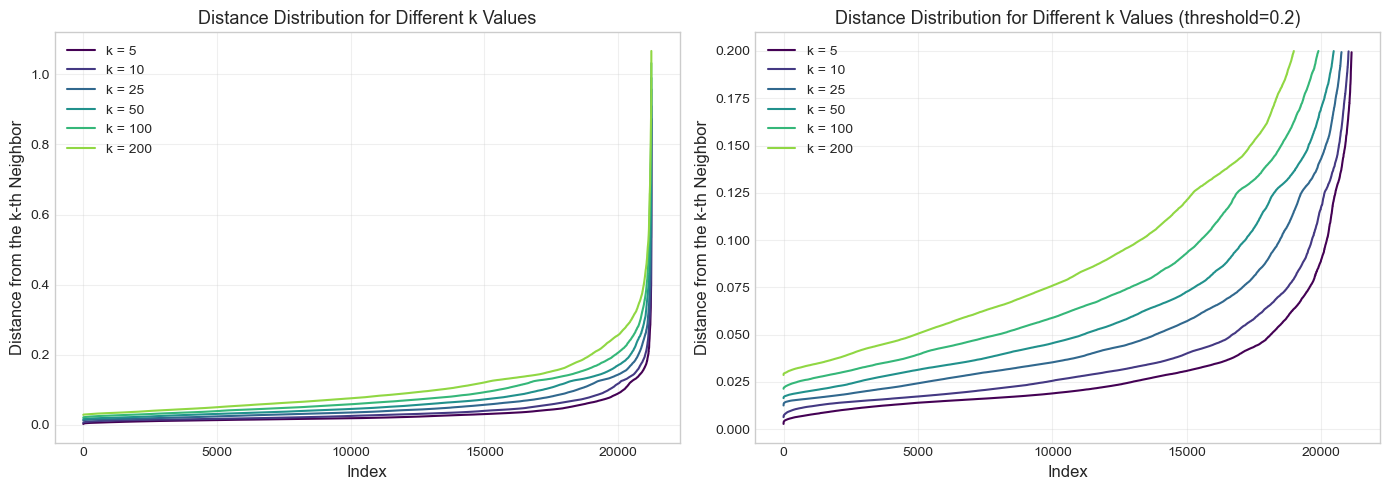


(a) full visualization without threshold          (b) visualization with a threshold of 0.2
Figure 2.7: K-th nearest neighbor analysis for k = [5, 10, 25, 50, 100, 200]


In [76]:
# Figure 2.7: K-th nearest neighbor analysis
def plot_knn_analysis(kth_distances_dict, k_values, threshold=0.1):
    """
    Visualizza l'analisi K-th nearest neighbor con due grafici:
    - (a) Visualizzazione completa senza threshold
    - (b) Visualizzazione con threshold per identificare il gomito
    
    Parameters:
    -----------
    kth_distances_dict : dict
        Dizionario con k come chiave e lista di distanze ordinate come valore
    k_values : list
        Lista dei valori di k analizzati
    threshold : float
        Soglia per il grafico zoomato (default 0.1)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # (a) Full visualization without threshold
    ax1 = axes[0]
    for idx, k in enumerate(k_values):
        color = plt.cm.viridis(idx / len(k_values))
        ax1.plot(range(len(kth_distances_dict[k])), kth_distances_dict[k], 
                 label=f'k = {k}', color=color, linewidth=1.5)
    
    ax1.set_xlabel('Index', fontsize=12)
    ax1.set_ylabel('Distance from the k-th Neighbor', fontsize=12)
    ax1.set_title('Distance Distribution for Different k Values', fontsize=13)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # (b) Visualization with threshold
    ax2 = axes[1]
    for idx, k in enumerate(k_values):
        color = plt.cm.viridis(idx / len(k_values))
        filtered = [d for d in kth_distances_dict[k] if d <= threshold]
        ax2.plot(range(len(filtered)), filtered, 
                 label=f'k = {k}', color=color, linewidth=1.5)
    
    ax2.set_xlabel('Index', fontsize=12)
    ax2.set_ylabel('Distance from the k-th Neighbor', fontsize=12)
    ax2.set_title(f'Distance Distribution for Different k Values (threshold={threshold})', fontsize=13)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('kth_neighbor_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n(a) full visualization without threshold          (b) visualization with a threshold of {threshold}")
    print(f"Figure 2.7: K-th nearest neighbor analysis for k = {k_values}")

# Esegui la visualizzazione
plot_knn_analysis(kth_distances_dict, k_values, threshold=0.2)

Based on the k-th nearest neighbor distance plot , a promising range for eps was estimated between 0.02 and 0.15. However, the absence of a clear elbow suggests that the dataset lacks well-defined density thresholds.

## 2.3.3 | Grid Search Exhaustive per DBSCAN

Dato che non è stato possibile identificare parametri adatti per risultati soddisfacenti, viene condotta una ricerca esaustiva variando:
- $k$ (minPts) da 5 a 50 (con step di 5)
- $\varepsilon$ da 0.02 a 0.15 (con step di 0.01)

Per ogni combinazione vengono registrati:
- Numero di punti di rumore
- Silhouette score
- Numero di cluster identificati

In [80]:
eps_range = np.arange(0.02, 0.155, 0.01)
min_samples_range = [5, 10, 15, 20, 25, 30, 35, 40, 45,50]

param_grid = list(ParameterGrid({'eps': eps_range, 'min_samples': min_samples_range}))
total_combinations = len(param_grid)

print(f"Range eps: {eps_range.min():.2f} - {eps_range.max():.2f} ({len(eps_range)} valori)")
print(f"Range minPts: {min(min_samples_range)} - {max(min_samples_range)} ({len(min_samples_range)} valori)")
print(f"Combinazioni totali: {total_combinations}")

Range eps: 0.02 - 0.15 (14 valori)
Range minPts: 5 - 50 (10 valori)
Combinazioni totali: 140


In [81]:
def summarize_labels(labels: np.ndarray):
    # labels: shape (n_samples,)
    n = labels.size
    noise_mask = (labels == -1)
    num_noise = int(noise_mask.sum())
    noise_ratio = num_noise / n

    # num_clusters = #etichette diverse escluso -1
    uniq = np.unique(labels)
    num_clusters = int((uniq != -1).sum())

    return num_clusters, num_noise, noise_ratio

In [82]:
all_results = []  # TUTTI i risultati
filtered_results = []  # solo quelli interessanti

for i, params in enumerate(param_grid, 1):
    eps = params['eps']
    min_samples = params['min_samples']
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(df_Z)
    num_clusters, num_noise, noise_ratio = summarize_labels(labels)
    
    if i == 1 or i % 100 == 0:
        print(
            f"Progress: {i}/{total_combinations} "
            f"({100*i/total_combinations:.1f}%) | "
            f"clusters={num_clusters} noise={noise_ratio:.2f}",
            flush=True
        )
    
    # Salva SEMPRE per analisi
    all_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'num_clusters': num_clusters,
        'num_noise': num_noise,
        'noise_ratio': noise_ratio
    })
    
    # Filtra per configurazioni interessanti
    if 3 <= num_clusters <= 15 and noise_ratio <= 0.80:
        filtered_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'num_clusters': num_clusters,
            'num_noise': num_noise,
            'noise_ratio': noise_ratio
        })

print(f"\nTotale: {len(all_results)}, Filtrate: {len(filtered_results)}")

Progress: 1/140 (0.7%) | clusters=224 noise=0.36
Progress: 100/140 (71.4%) | clusters=7 noise=0.11

Totale: 140, Filtrate: 96


In [83]:
df_fast = pd.DataFrame(filtered_results)
df_fast = df_fast.sort_values(by=['noise_ratio', 'num_clusters'], ascending=[True, False]).reset_index(drop=True)

top_k = 20  # quante config valutare con silhouette
candidates = df_fast.head(top_k).to_dict('records')

print(f"\nCalcolo silhouette sulle top-{top_k} config (post-filtri)...\n")


Calcolo silhouette sulle top-20 config (post-filtri)...



In [84]:
# Analisi silhouette sulle migliori configurazioni filtrate
df_fast = pd.DataFrame(filtered_results)
df_fast = df_fast.sort_values(by=['noise_ratio', 'num_clusters'], ascending=[True, False]).reset_index(drop=True)

top_k = 20
candidates = df_fast.head(top_k).to_dict('records')
print(f"Calcolo silhouette sulle top-{top_k} config (post-filtri)...\n")

detailed = []
for j, cfg in enumerate(candidates, 1):
    eps = cfg['eps']
    min_samples = cfg['min_samples']
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(df_Z)
    
    mask = labels != -1
    labels_nn = labels[mask]
    
    if labels_nn.size < 2 or len(np.unique(labels_nn)) < 2:
        sil = np.nan
    else:
        sil = silhouette_score(df_Z[mask], labels_nn, metric='euclidean')
    
    detailed.append({**cfg, 'silhouette': sil})
    print(f"[{j}/{top_k}] eps={eps:.2f}, minPts={min_samples:3d} | "
          f"clusters={cfg['num_clusters']}, noise={cfg['noise_ratio']:.2f}, sil={sil:.3f}" if not np.isnan(sil) else f"[{j}/{top_k}] eps={eps:.2f}, minPts={min_samples:3d} | clusters={cfg['num_clusters']}, noise={cfg['noise_ratio']:.2f}, sil=NaN")

Calcolo silhouette sulle top-20 config (post-filtri)...

[1/20] eps=0.15, minPts=  5 | clusters=9, noise=0.01, sil=-0.010
[2/20] eps=0.14, minPts=  5 | clusters=9, noise=0.01, sil=0.007
[3/20] eps=0.13, minPts=  5 | clusters=15, noise=0.01, sil=-0.012
[4/20] eps=0.15, minPts= 15 | clusters=3, noise=0.02, sil=0.327
[5/20] eps=0.13, minPts= 10 | clusters=3, noise=0.02, sil=0.321
[6/20] eps=0.15, minPts= 30 | clusters=3, noise=0.03, sil=0.306
[7/20] eps=0.12, minPts= 10 | clusters=12, noise=0.04, sil=-0.006
[8/20] eps=0.14, minPts= 40 | clusters=3, noise=0.04, sil=0.290
[9/20] eps=0.14, minPts= 45 | clusters=3, noise=0.04, sil=0.290
[10/20] eps=0.11, minPts= 10 | clusters=11, noise=0.04, sil=-0.019
[11/20] eps=0.12, minPts= 15 | clusters=10, noise=0.04, sil=-0.018
[12/20] eps=0.13, minPts= 30 | clusters=3, noise=0.04, sil=0.295
[13/20] eps=0.14, minPts= 50 | clusters=3, noise=0.04, sil=0.281
[14/20] eps=0.13, minPts= 35 | clusters=3, noise=0.05, sil=0.283
[15/20] eps=0.10, minPts= 10 | cl

# Best Configuration Selected

In [85]:
db = DBSCAN(eps=0.15, min_samples=15, metric='euclidean')
labels = db.fit_predict(df_Z)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

def plot_pca_clusters_pretty(
    X_scaled,
    labels,
    title: str,
    clip=(1, 99),
    random_state: int = 42,
    figsize=(7, 5),
    s: int = 12,
    alpha_clusters: float = 0.70,
    alpha_noise: float = 0.35,
    noise_color: str = "#a19c9c",
):
    """
    PCA (2D) cluster visualization with:
    - custom pastel palette for clusters
    - light-grey noise points
    - legend with cluster -> color mapping
    - PC axis labels include explained variance %
    - optional percentile clipping of axes for readability
    """
    labels = np.asarray(labels)

    # --- PCA projection
    pca = PCA(n_components=2, random_state=random_state)
    X2 = pca.fit_transform(X_scaled)
    evr = pca.explained_variance_ratio_
    pc1_pct = 100 * float(evr[0])
    pc2_pct = 100 * float(evr[1])

    fig, ax = plt.subplots(figsize=figsize)

    # --- palette requested (pastel-ish)
    TAB10_FIRST7 = [
        "#6992DE",  # soft blue
        "#F68B5E",  # soft orange
        "#77C877",  # soft green
        "#E689B9",  # soft pink
        "#FED156",  # soft yellow
        "#A986C7",  # soft purple
        "#98D4D4",  # soft teal
        "#9A2D2D",  # soft red
    ]

    # --- separate noise vs clusters
    noise_mask = labels == -1
    cluster_mask = ~noise_mask

    # plot noise first (behind)
    if np.any(noise_mask):
        ax.scatter(
            X2[noise_mask, 0],
            X2[noise_mask, 1],
            c=noise_color,
            s=s,
            alpha=alpha_noise,
            edgecolors="none",
            rasterized=True,
            zorder=1,
        )

    # plot clusters with explicit color mapping (not a colormap)
    uniq_clusters = np.unique(labels[cluster_mask]) if np.any(cluster_mask) else np.array([])
    uniq_clusters = np.sort(uniq_clusters)

    handles = []
    if uniq_clusters.size > 0:
        for i, cl in enumerate(uniq_clusters):
            col = TAB10_FIRST7[i % len(TAB10_FIRST7)]
            m = labels == cl
            ax.scatter(
                X2[m, 0],
                X2[m, 1],
                c=col,
                s=s,
                alpha=alpha_clusters,
                edgecolors="none",
                rasterized=True,
                zorder=2,
            )
            handles.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    color="none",
                    markerfacecolor=col,
                    markersize=7,
                    label=f"Cluster {int(cl)}"
                )
            )

    # add noise legend handle (last)
    if np.any(noise_mask):
        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                color="none",
                markerfacecolor=noise_color,
                markersize=7,
                label="Noise"
            )
        )

    # --- axis clipping
    xlim = np.percentile(X2[:, 0], clip)
    ylim = np.percentile(X2[:, 1], clip)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # --- labels with variance %
    ax.set_xlabel(f"PC1 ({pc1_pct:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pc2_pct:.1f}% var)")
    ax.set_title(str(title))

    # --- legend (outside to avoid covering points)
    if handles:
        ax.legend(
            handles=handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            frameon=True,
            fontsize=9,
            borderaxespad=0.0,
        )

    plt.tight_layout()
    plt.show()

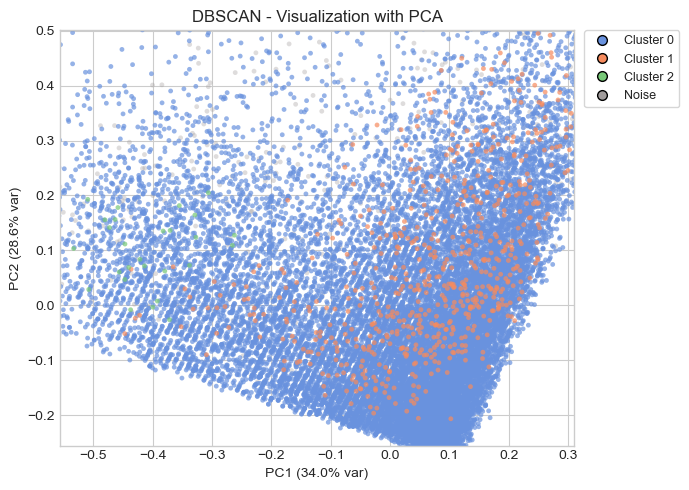

In [87]:
plot_pca_clusters_pretty(
    df_Z,
    labels,
    title=f"DBSCAN - Visualization with PCA",
)

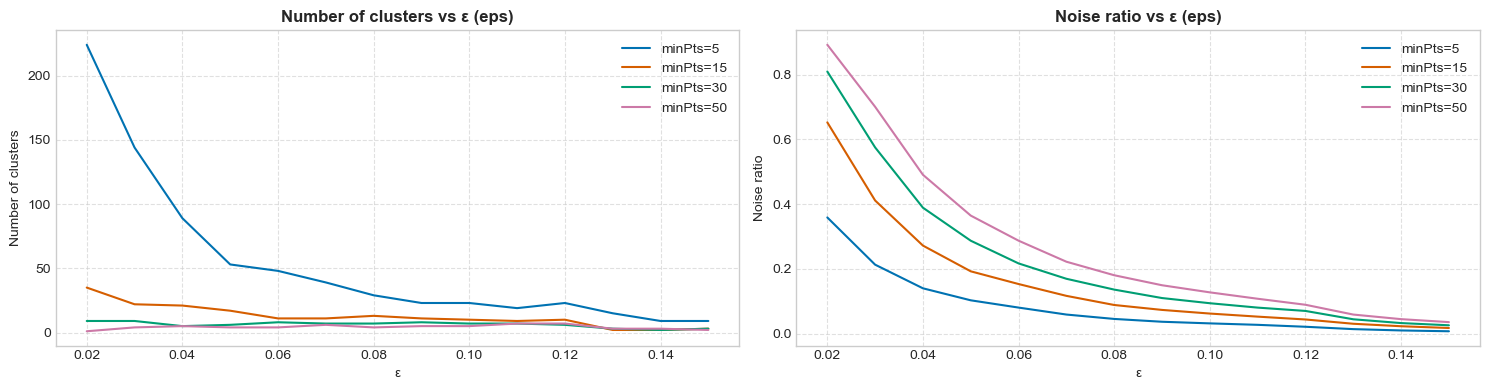

Configurazioni con 1 cluster: 2
Configurazioni con 2+ cluster: 138
Noise ratio medio: 19.65%


In [116]:
# Analisi del comportamento al variare dei parametri
results_df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

for i, min_s in enumerate([5, 15, 30, 50]):
    subset = results_df[results_df['min_samples'] == min_s]
    axes[0].plot(subset['eps'], subset['num_clusters'], label=f'minPts={min_s}', color=colors[i])
    axes[1].plot(subset['eps'], subset['noise_ratio'], label=f'minPts={min_s}', color=colors[i])

axes[0].set_xlabel('ε'); axes[0].set_ylabel('Number of clusters'); axes[0].set_title('Number of clusters vs ε (eps)', fontweight='bold')
axes[1].set_xlabel('ε'); axes[1].set_ylabel('Noise ratio'); axes[1].set_title('Noise ratio vs ε (eps)', fontweight='bold')
axes[0].legend(); axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[0].grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

print(f"Configurazioni con 1 cluster: {(results_df['num_clusters'] == 1).sum()}")
print(f"Configurazioni con 2+ cluster: {(results_df['num_clusters'] >= 2).sum()}")
print(f"Noise ratio medio: {results_df['noise_ratio'].mean():.2%}")

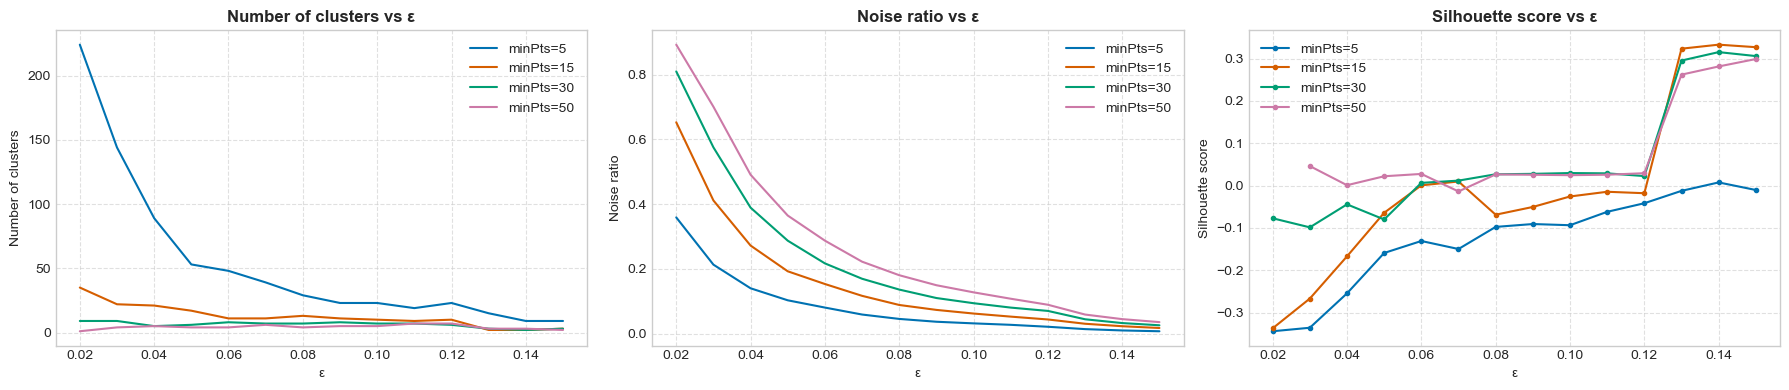

Configurazioni con 1 cluster: 2
Configurazioni con 2+ cluster: 138
Noise ratio medio: 19.65%


In [119]:
# Analisi del comportamento al variare dei parametri
results_df = pd.DataFrame(all_results)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

# Calcola silhouette per ogni configurazione
sil_results = []
for eps in results_df['eps'].unique():
    for min_s in [5, 15, 30, 50]:
        subset = results_df[(results_df['eps'] == eps) & (results_df['min_samples'] == min_s)]
        if len(subset) > 0:
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(df_Z)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            mask = labels != -1
            if n_clusters >= 2 and sum(mask) > 1:
                sil = silhouette_score(df_Z[mask], labels[mask])
            else:
                sil = np.nan
            sil_results.append({'eps': eps, 'min_samples': min_s, 'silhouette': sil})

sil_df = pd.DataFrame(sil_results)

# Plot 1: Clusters vs ε
for i, min_s in enumerate([5, 15, 30, 50]):
    subset = results_df[results_df['min_samples'] == min_s]
    axes[0].plot(subset['eps'], subset['num_clusters'], label=f'minPts={min_s}', color=colors[i])
axes[0].set_xlabel('ε')
axes[0].set_ylabel('Number of clusters')
axes[0].set_title('Number of clusters vs ε', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Noise vs ε
for i, min_s in enumerate([5, 15, 30, 50]):
    subset = results_df[results_df['min_samples'] == min_s]
    axes[1].plot(subset['eps'], subset['noise_ratio'], label=f'minPts={min_s}', color=colors[i])
axes[1].set_xlabel('ε')
axes[1].set_ylabel('Noise ratio')
axes[1].set_title('Noise ratio vs ε', fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Silhouette vs ε
for i, min_s in enumerate([5, 15, 30, 50]):
    subset = sil_df[sil_df['min_samples'] == min_s]
    axes[2].plot(subset['eps'], subset['silhouette'], label=f'minPts={min_s}', color=colors[i], marker='o', markersize=3)
axes[2].set_xlabel('ε')
axes[2].set_ylabel('Silhouette score')
axes[2].set_title('Silhouette score vs ε', fontweight='bold')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Configurazioni con 1 cluster: {(results_df['num_clusters'] == 1).sum()}")
print(f"Configurazioni con 2+ cluster: {(results_df['num_clusters'] >= 2).sum()}")
print(f"Noise ratio medio: {results_df['noise_ratio'].mean():.2%}")

## Interpretation of DBSCAN Grid Search Results

### Number of Clusters vs ε (Left Panel)

The number of clusters decreases rapidly as ε increases. At ε = 0.02–0.04, low minPts values (5–15) produce over 100 clusters, indicating severe over-fragmentation. As ε approaches 0.08–0.10, most configurations converge to 10–30 clusters. For ε > 0.12, nearly all configurations yield fewer than 10 clusters regardless of minPts.

Higher minPts values consistently produce fewer clusters across all ε values, as fewer points satisfy the core point criterion.

### Noise Ratio vs ε (Middle Panel)

The noise ratio exhibits a clear inverse relationship with ε. At ε = 0.02, noise exceeds 80% for minPts = 5 and remains above 20% for all configurations. As ε increases to 0.06–0.08, noise drops to 5–20% depending on minPts. For ε > 0.10, noise approaches 0% for most configurations.

Higher minPts values produce more noise at the same ε, as the stricter density requirement excludes more points from cluster membership.

### Silhouette Score vs ε (Right Panel)

The silhouette score reveals the quality of cluster separation. At low ε values (0.02–0.04), silhouette scores are strongly negative (−0.35 to −0.10), indicating that points are, on average, closer to neighboring clusters than to their own—a sign of severe over-fragmentation.

As ε increases, silhouette scores improve progressively. For ε > 0.12, scores become positive (0.20–0.35), with higher minPts values achieving slightly better separation. However, this apparent improvement is misleading: at these ε values, nearly all points collapse into a single dominant cluster, and the positive silhouette reflects trivial separation rather than meaningful structure.

Notably, minPts = 5 (blue curve) exhibits erratic behavior across the ε range, while higher minPts values show more stable trajectories.

### Summary Statistics

| Metric | Value |
|--------|-------|
| Single-cluster configurations | 2 |
| Multi-cluster configurations | 138 |
| Average noise ratio | 19.65% |

### Key Findings

The analysis reveals an inherent trade-off: reducing noise (higher ε) inevitably reduces cluster granularity, while achieving positive silhouette scores requires collapsing the data into few, highly imbalanced clusters. No configuration simultaneously achieves low noise, meaningful cluster count, and positive silhouette score—confirming that the dataset's dense, uniform structure is unsuitable for density-based clustering with DBSCAN.

In [92]:
def describe_clusters(data, eps, min_samples, title="Cluster Analysis"):
    """
    Mostra la distribuzione percentuale dei cluster.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(data)
    
    print(f"\n{title} (ε={eps}, minPts={min_samples})")
    print("-" * 40)
    
    unique, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique, counts):
        pct = 100 * count / len(labels)
        name = "Noise" if label == -1 else f"Cluster {label}"
        print(f"  {name}: {count} ({pct:.1f}%)")

# All features
describe_clusters(df_Z, eps=0.15, min_samples=15)




Cluster Analysis (ε=0.15, minPts=15)
----------------------------------------
  Noise: 371 (1.7%)
  Cluster 0: 20192 (95.0%)
  Cluster 1: 654 (3.1%)
  Cluster 2: 27 (0.1%)


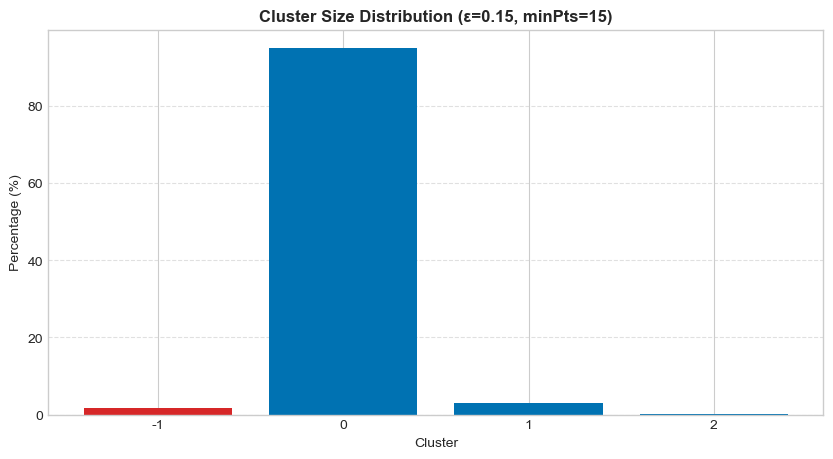

In [118]:
# Per la migliore configurazione
db = DBSCAN(eps=0.15, min_samples=15)
labels = db.fit_predict(df_Z)

# Conta dimensioni cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = pd.DataFrame({'Cluster': unique, 'Size': counts})
cluster_sizes['Percentage'] = 100 * cluster_sizes['Size'] / len(labels)

# Barplot
plt.figure(figsize=(10, 5))
colors = ['#d62728' if c == -1 else '#0072B2' for c in cluster_sizes['Cluster']]
plt.bar(cluster_sizes['Cluster'].astype(str), cluster_sizes['Percentage'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.title('Cluster Size Distribution (ε=0.15, minPts=15)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.show()